In [11]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END,add_messages
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import BaseModel,Field
from langchain_community.vectorstores import FAISS

In [2]:
loader1 = PyPDFLoader("documents/book1.pdf")
loader2 = PyPDFLoader("documents/book2.pdf")
loader3 = PyPDFLoader("documents/book3.pdf")

In [3]:
docs = loader1.load() + loader2.load() + loader3.load()
len(docs)

2123

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap = 200
)

chunk = splitter.split_documents(docs)

len(chunk)

5918

In [58]:
load_dotenv()

model = ChatOpenAI()

parser1 = StrOutputParser()

In [6]:
embedding = OpenAIEmbeddings()

parser = StrOutputParser()

vector_store = FAISS.from_documents(
        embedding=embedding,
        documents=chunk
)

In [7]:
retriever = vector_store.as_retriever(
    search_type = 'mmr',
    serach_kwargs = {'k':4}
)

In [38]:
class RagState(TypedDict):

    question : str
    documents : List[Document]

    strip : List[str]
    kept_strip : List[str]
    refined_content : str

    answer : str

In [39]:
class KeepOrDrop(BaseModel):

    keep : bool = Field(description='True or False')

parser = PydanticOutputParser(pydantic_object=KeepOrDrop)

In [40]:
def retrieve(state:RagState)->dict:

    question = state['question']

    response = retriever.invoke(question)

    return {'documents':response}

In [41]:
import re

def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [54]:
def refine(state:RagState)->dict:

    refined_content = state.get('refined_content',"")

    question = state['question']

    documents = state['documents']

    context = '\n'.join(f"- {docs.page_content}" for docs in documents)

    strips = decompose_to_sentences(context)

    template = ChatPromptTemplate([
        ('system',
         "You are a strict relevance filter.\n"
        "Return keep=true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentence. Output JSON only. \n {format_instruction}"),
        ('user',"Question: {question}\n\nSentence:\n{sentence}")
    ],
    input_variables = ['question','sentence'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
    )

    kept : List[str] =[]
    chain = template | model | parser
    for s in strips:
        keep_drop : KeepOrDrop = chain.invoke({'question':question,'sentence':s})
        keep_drop_dict = keep_drop.model_dump()
        if keep_drop_dict['keep']:
            kept.append(s)

    refined_content = ''.join(kept).strip()

    return {
        'strips':strips,
        'keep_strip':kept,
        'refined_content':refined_content
    }

In [59]:
def generate(state:RagState)->dict:

    question = state['question']
    documents = state['documents']
    
    content = '\n'.join(f" - {docs.page_content}" for docs in documents)


    template = ChatPromptTemplate([
        ('system',"Answer only from the context provided, if not in context say you don't know. \n {content}"),
        ('user',"{question}")
    ],
    input_variables = ['content','question']
    )

    chain = template | model | parser1

    response = chain.invoke({'content':content,'question':question})

    return {'answer':response}

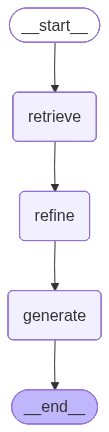

In [60]:
graph = StateGraph(RagState)
graph.add_node('retrieve',retrieve)
graph.add_node('refine',refine)
graph.add_node('generate',generate)

graph.add_edge(START,'retrieve')
graph.add_edge('retrieve','refine')
graph.add_edge('refine','generate')
graph.add_edge('generate',END)

chatbot = graph.compile()

chatbot

In [61]:
response = chatbot.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(response["answer"])

The bias-variance trade-off refers to the trade-off between bias and variance in a model. Bias measures the expected deviation from the true value of the function or parameter, while variance measures the deviation from the expected estimator value that any particular sampling of the data is likely to cause. Models with high flexibility have low bias but high variance, while relatively rigid models have high bias but low variance. The optimal model is the one that strikes the best balance between bias and variance, leading to the best predictive capability. This trade-off illustrates the need to find a model complexity that minimizes the overall error, taking into account both bias and variance.


In [62]:
print(response['documents'][0].page_content)
print('*'*100)
print(response['documents'][1].page_content)
print('*'*100)
print(response['documents'][2].page_content)
print('*'*100)
print(response['documents'][3].page_content)

sum of a (squared) bias, a variance, and a constant noise term. As we shall see, there
is a trade-off between bias and variance, with very ﬂexible models having low bias
and high variance, and relatively rigid models having high bias and low variance.
The model with the optimal predictive capability is the one that leads to the best
balance between bias and variance. This is illustrated by considering the sinusoidal
data set from Chapter 1. Here we generate 100 data sets, each containing N =2 5Appendix A
data points, independently from the sinusoidal curve h(x)=s i n ( 2πx). The data
sets are indexed by l =1 ,...,L , where L = 100, and for each data set D
(l) we
****************************************************************************************************
CHAPTER5.MACHINELEARNINGBASICS
Example: BernoulliDistributionWeonceagainconsiderasetofsamples
{x(1),...,x()m}drawnindependentlyandidenticallyfromaBernoullidistribution
(recallP(x()i;θ) =θx()i
(1−θ)(1−x()i)).Thistimeweareinterest

In [64]:
print(response['refined_content'])

- sum of a (squared) bias, a variance, and a constant noise term.As we shall see, there is a trade-off between bias and variance, with very ﬂexible models having low bias and high variance, and relatively rigid models having high bias and low variance.The model with the optimal predictive capability is the one that leads to the best balance between bias and variance.This is illustrated by considering the sinusoidal data set from Chapter 1.Var  ˆθm  = Var  1 m m i=1 x()i  (5.48) =1 m2 m i=1 Var  x()i  (5.49) =1 m2 m i=1 θ θ(1−) (5.50) =1 m2mθ θ(1−) (5.51) =1 mθ θ(1−) (5.52) Thevarianceoftheestimatordecreasesasafunctionofm,thenumberofexamples inthedataset.Thisisacommonpropertyofpopularestimatorsthatwewill returntowhenwediscussconsistency(seesection).5.4.5 5.4.4TradingoﬀBiasandVariancetoMinimizeMeanSquared Error Biasandvariancemeasuretwodiﬀerentsourcesoferrorinanestimator.Bias measurestheexpecteddeviationfromthetruevalueofthefunctionorparameter.Varianceontheotherhand,providesamea